# Edge Transformer Policy — Multi-Env Training
Train the edge-token transformer on any checker. Each of the E = n(n-1)/2 edge slots is a
sequence token with features `[exists, deg_i, deg_j, common_neighbors]`. Attention is biased
by a static share-a-node matrix so adjacent edges attend to each other.

Checkpoints saved to `./checkpoints_edge_{checker_name}_n{N}/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import torch
import numpy as np
import matplotlib.pyplot as plt

from turan_env_c import (
    CEnv,
    CHECKER_C3, CHECKER_C4, CHECKER_C3C4,
    CHECKER_K23, CHECKER_THETA123, CHECKER_BULL,
    CHECKER_BOWTIE, CHECKER_K4,
)
from edge_transformer_policy import EdgeTransformerPolicy
from ppo_edge import CFG, train, load_checkpoint, run_episodes

print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")
    
    
    
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

/root/backtoRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch 2.10.0+cu130  cuda=True
  NVIDIA H100 80GB HBM3


## Pick your setup
Edit the two cells below, then run all.

In [38]:
# ── CHANGE THESE ──────────────────────────────────────────────────────────────
CHECKER = CHECKER_C3   # CHECKER_C3 | CHECKER_C4 | CHECKER_K4 | ...
N       = 30         # graph size
RESUME  = './checkpoints_edge_c3_n20/best.pt'       # e.g. './checkpoints_edge_c3_n20/best.pt'
TRAIN   = False    # set False to skip training and load RESUME for eval only

# Policy architecture
D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 2
# ──────────────────────────────────────────────────────────────────────────────

CHECKER_NAMES = {
    CHECKER_C3:       'c3',
    CHECKER_C4:       'c4',
    CHECKER_C3C4:     'c3c4',
    CHECKER_K23:      'k23',
    CHECKER_THETA123: 'theta123',
    CHECKER_BULL:     'bull',
    CHECKER_BOWTIE:   'bowtie',
    CHECKER_K4:       'k4',
}

KNOWN_BOUNDS = {
    CHECKER_C3: N**2 // 4,
    CHECKER_C4: None,
    CHECKER_K4: N**2 // 3,
}

checker_name = CHECKER_NAMES[CHECKER]
ckpt_dir     = f'./checkpoints_edge_{checker_name}_n{N}'
bound        = KNOWN_BOUNDS.get(CHECKER)

print(f"Checker  : {checker_name}  (id={CHECKER})")
print(f"N        : {N}")
print(f"Bound    : {bound if bound else 'unknown'}")
print(f"Ckpt dir : {ckpt_dir}")
print(f"Train    : {TRAIN}  |  Resume: {RESUME}")
print(f"Policy   : d={D_MODEL}  heads={N_HEADS}  layers={N_LAYERS}")

Checker  : c3  (id=0)
N        : 30
Bound    : 225
Ckpt dir : ./checkpoints_edge_c3_n30
Train    : False  |  Resume: ./checkpoints_edge_c3_n20/best.pt
Policy   : d=64  heads=4  layers=2


In [39]:
cfg = {**CFG}   # copy defaults

cfg['n']              = N
cfg['checker_id']     = CHECKER
cfg['checkpoint_dir'] = ckpt_dir

# Policy architecture (stored in cfg so checkpoints are self-describing)
cfg['d_model']  = D_MODEL
cfg['n_heads']  = N_HEADS
cfg['n_layers'] = N_LAYERS

# ── hyperparams (edit freely, these override the checkpoint when resuming) ──
cfg['total_steps'] = 1_000_000
cfg['lr']          = 3e-4
cfg['ent_coef']    = 0.07
cfg['num_envs']    = 1024

for k, v in cfg.items():
    print(f"  {k:20s} = {v}")

  n                    = 30
  num_envs             = 1024
  checker_id           = 0
  n_steps              = 64
  n_epochs             = 10
  batch_size           = 2048
  lr                   = 0.0003
  gamma                = 0.99
  gae_lambda           = 0.95
  clip_eps             = 0.2
  vf_coef              = 0.5
  ent_coef             = 0.07
  max_grad_norm        = 0.5
  total_steps          = 1000000
  device               = cuda
  log_interval         = 10
  save_interval        = 100
  checkpoint_dir       = ./checkpoints_edge_c3_n30
  d_model              = 64
  n_heads              = 4
  n_layers             = 2


## Env sanity + benchmark

In [40]:
env = CEnv(n=N, num_envs=cfg['num_envs'], checker_id=CHECKER)
obs = env.reset()
print(f"obs shape  : {obs.shape}   dtype: {obs.dtype}")
print(f"num_actions: {env.num_actions}  (= {N}*{N-1}/2)")
env.benchmark(steps=200)
env.close()

# Policy param count
p = EdgeTransformerPolicy(D_MODEL, N_HEADS, N_LAYERS)
print(f"\nPolicy params: {sum(x.numel() for x in p.parameters()):,}")
del p

obs shape  : (1024, 435)   dtype: bool
num_actions: 435  (= 30*29/2)
200 steps x 1024 envs in 0.02s
  11,878,332 steps/sec
  11.88M steps/sec

Policy params: 71,043


## Train

In [41]:
if TRAIN:
    policy, history = train(cfg=cfg, resume=RESUME)
else:
    assert RESUME and os.path.exists(RESUME), \
        f"Set RESUME to a valid checkpoint path when TRAIN=False (got: {RESUME})"
    policy, _, cfg, _, _, _ = load_checkpoint(RESUME)
    policy.eval()
    history = []
    print(f"Loaded checkpoint: {RESUME} (training skipped)")

loaded ./checkpoints_edge_c3_n20/best.pt  iter=84  steps=4,931,584  best=81.03
Loaded checkpoint: ./checkpoints_edge_c3_n20/best.pt (training skipped)


## Training curves

In [42]:
if not history:
    print("No training history — run training or load a checkpoint with TRAIN=True.")
else:
    steps = [h['global_step'] / 1e6 for h in history]
    rets  = [h['mean_ret'] for h in history]
    pg    = [h['pg']       for h in history]
    vf    = [h['vf']       for h in history]
    ent   = [h['ent']      for h in history]
    fps_h = [h['fps']      for h in history]

    def smooth(vals, frac=0.05):
        w = max(1, int(len(vals) * frac))
        return np.convolve(vals, np.ones(w) / w, mode='valid'), w

    COLORS = dict(ret='#2196F3', pg='#9C27B0', vf='#009688',
                  ent='#FF5722', fps='#607D8B', bound='#F44336')

    fig, axes = plt.subplots(2, 3, figsize=(22, 11))
    fig.patch.set_facecolor('#f5f5f5')

    for ax in axes.flat:
        ax.set_facecolor('#ffffff')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
        ax.tick_params(labelsize=10)

    def plot_with_smooth(ax, xs, ys, color, label=None):
        ax.plot(xs, ys, color=color, alpha=0.2, linewidth=0.8)
        sm, w = smooth(ys)
        ax.plot(xs[w-1:], sm, color=color, linewidth=2.5, label=label)

    plot_with_smooth(axes[0,0], steps, rets, COLORS['ret'])
    if bound:
        axes[0,0].axhline(bound, color=COLORS['bound'], linestyle='--', linewidth=1.8, label=f'bound={bound}')
        axes[0,0].legend(fontsize=10)
    axes[0,0].set_title('Mean Return', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Steps (M)', fontsize=11)

    plot_with_smooth(axes[0,1], steps, pg, COLORS['pg'])
    axes[0,1].set_title('Policy Loss', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Steps (M)', fontsize=11)

    plot_with_smooth(axes[0,2], steps, vf, COLORS['vf'])
    axes[0,2].set_title('Value Loss', fontsize=14, fontweight='bold')
    axes[0,2].set_xlabel('Steps (M)', fontsize=11)

    plot_with_smooth(axes[1,0], steps, ent, COLORS['ent'])
    axes[1,0].set_title('Entropy', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Steps (M)', fontsize=11)

    axes[1,1].plot(steps, fps_h, color=COLORS['fps'], linewidth=1.5)
    axes[1,1].set_title('FPS', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Steps (M)', fontsize=11)
    axes[1,1].set_facecolor('#ffffff')
    axes[1,1].spines[['top', 'right']].set_visible(False)
    axes[1,1].grid(True, alpha=0.25, linestyle='--', linewidth=0.8)

    ax = axes[1,2]
    if bound:
        ratio = [r / bound for r in rets]
        plot_with_smooth(ax, steps, ratio, COLORS['ret'])
        ax.axhline(1.0, color=COLORS['bound'], linestyle='--', linewidth=1.8, label='100% of bound')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        ax.legend(fontsize=10)
        ax.set_title('Return / Bound', fontsize=14, fontweight='bold')
    else:
        plot_with_smooth(ax, steps, rets, COLORS['ret'])
        ax.set_title('Return (smoothed)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Steps (M)', fontsize=11)

    best_ret = max(rets)
    pct_str = f'   ({best_ret/bound*100:.1f}% of bound={bound})' if bound else ''
    fig.suptitle(
        f'EdgeTransformer — {checker_name.upper()}   n={N}   best={best_ret:.2f}{pct_str}',
        fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

No training history — run training or load a checkpoint with TRAIN=True.


## Evaluate — draw the densest graph found

Edge counts : [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100]
Best found  : 100  (44.4% of bound=225)

  VALID : all 100 edges pass C3 constraint


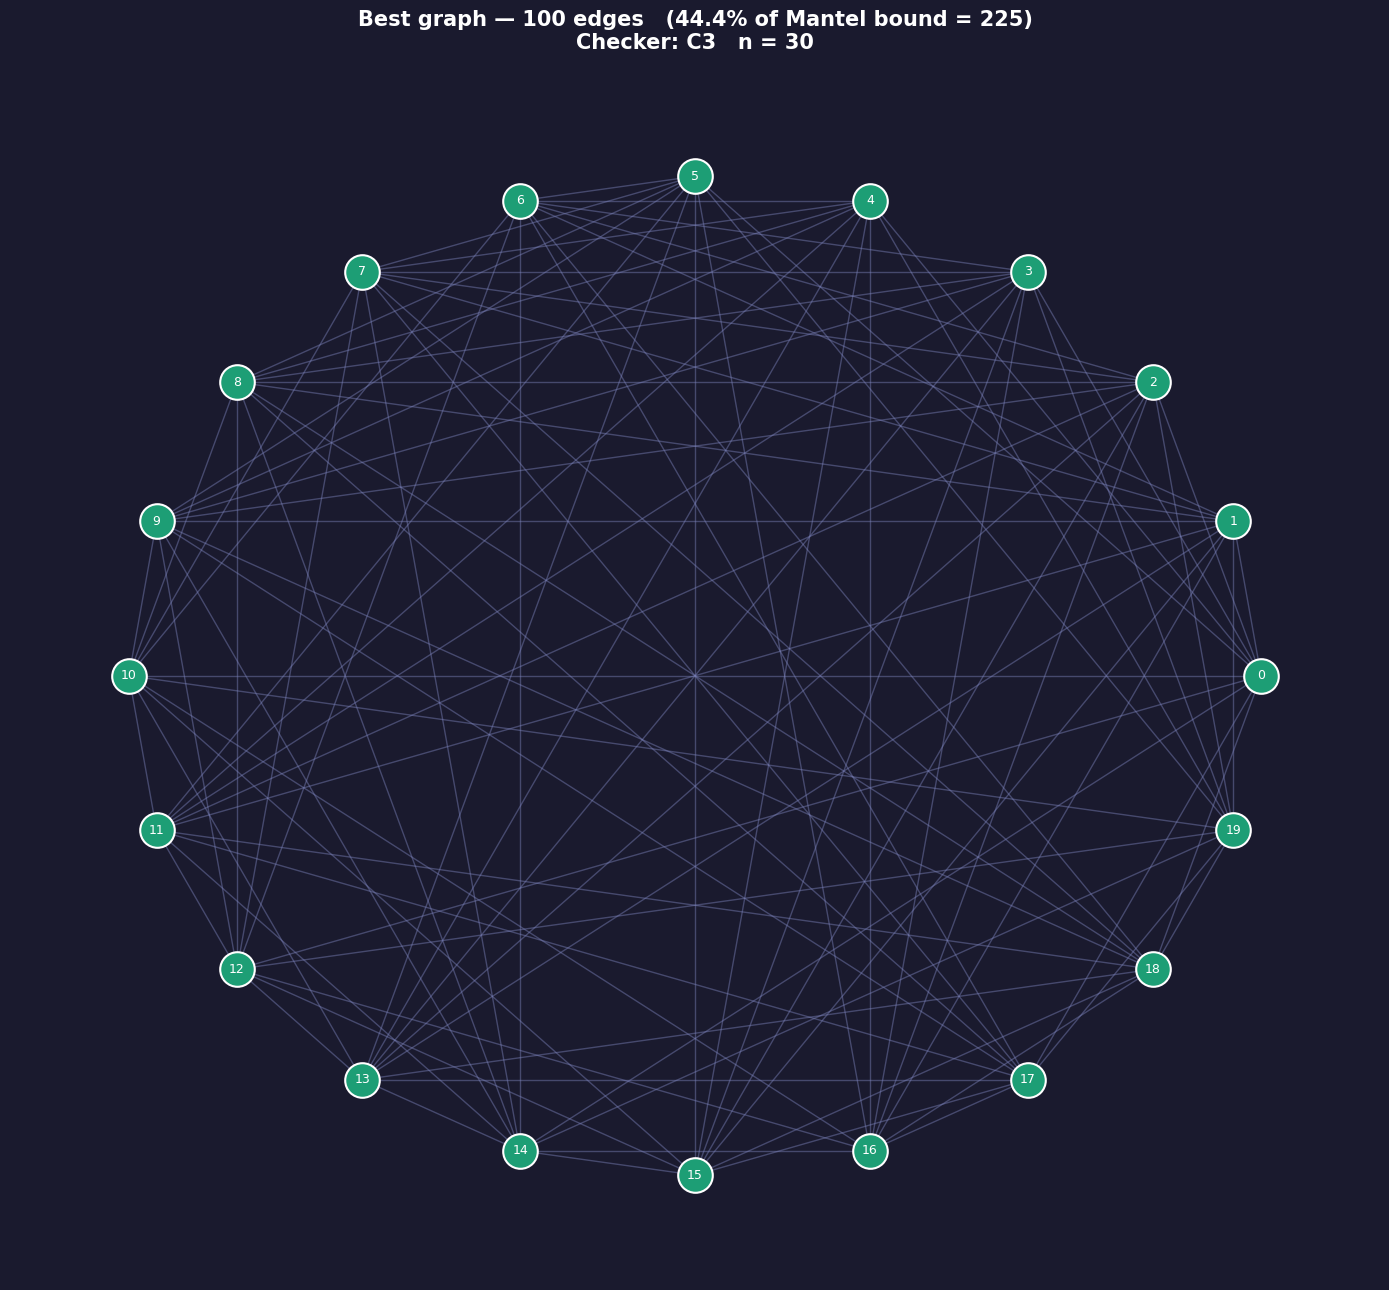

In [43]:
import networkx as nx
from checkers import (
    C3Checker, C4Checker, C3C4Checker,
    K23Checker, Theta123Checker, BullChecker, BowTieChecker,
)

CHECKER_CLASS_MAP = {
    CHECKER_C3:       C3Checker,
    CHECKER_C4:       C4Checker,
    CHECKER_C3C4:     C3C4Checker,
    CHECKER_K23:      K23Checker,
    CHECKER_THETA123: Theta123Checker,
    CHECKER_BULL:     BullChecker,
    CHECKER_BOWTIE:   BowTieChecker,
}

policy.eval()
adjs = run_episodes(policy, cfg, n_episodes=16, deterministic=True)

edge_counts = [int(adj.sum()) // 2 for adj in adjs]
best_adj    = adjs[np.argmax(edge_counts)].copy()
best_edges  = max(edge_counts)
n_graph     = best_adj.shape[0]

print(f"Edge counts : {sorted(edge_counts, reverse=True)}")
print(f"Best found  : {best_edges}" +
      (f"  ({best_edges/bound*100:.1f}% of bound={bound})" if bound else ''))

# ── Checker verification ──────────────────────────────────────────────────────
if CHECKER in CHECKER_CLASS_MAP:
    checker    = CHECKER_CLASS_MAP[CHECKER](n_graph)
    violations = []
    for u in range(n_graph):
        for v in range(u + 1, n_graph):
            if best_adj[u][v]:
                best_adj[u][v] = best_adj[v][u] = 0          # remove edge
                bad = checker.check(best_adj.astype(bool), u, v)           # would adding it violate?
                best_adj[u][v] = best_adj[v][u] = 1          # restore
                if bad:
                    violations.append((u, v))
    if violations:
        print(f"\n  INVALID: {len(violations)} edge(s) violate {checker_name.upper()} — "
              f"{violations[:5]}{'...' if len(violations) > 5 else ''}")
    else:
        print(f"\n  VALID : all {best_edges} edges pass {checker_name.upper()} constraint")
else:
    print(f"\n(No Python checker registered for '{checker_name}' — skipping verification)")

# ── Graph layout ──────────────────────────────────────────────────────────────
G = nx.from_numpy_array(best_adj)
if n_graph <= 20:
    pos = nx.circular_layout(G)
elif n_graph <= 60:
    pos = nx.kamada_kawai_layout(G)
else:
    pos = nx.spring_layout(G, seed=42, k=2.5 / n_graph**0.5, iterations=60)

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 13))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color='#7c83bc', alpha=0.45, width=1.0)
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color='#1D9E75',
    node_size=max(80, 900 - n_graph * 14),
    linewidths=1.5, edgecolors='#ffffff')

if n_graph <= 40:
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        font_color='white', font_size=max(6, 11 - n_graph // 8))

pct_str = f'   ({best_edges / bound * 100:.1f}% of Mantel bound = {bound})' if bound else ''
ax.set_title(
    f"Best graph — {best_edges} edges{pct_str}\n"
    f"Checker: {checker_name.upper()}   n = {N}",
    fontsize=15, fontweight='bold', color='white', pad=16)
ax.axis('off')
plt.tight_layout()
plt.show()